### Ingestão de Dados e Mapeamento de Classes

Em tarefas de segmentação semântica multiclasse, as máscaras originais são codificadas em cores visuais (RGB). Para que a função de perda da rede neural possa otimizar os pesos, precisamos converter essas matrizes de cores em **índices categóricos esparsos** (variando de 0 a $N-1$ classes). O dicionário abaixo estabelece a relação entre a assinatura visual do dataset de Dubai e o vetor de classes do modelo.

In [1]:
import os
import glob
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Mapeamento das imagens e máscaras
image_paths = sorted(glob.glob(os.path.join('data', 'Semantic segmentation dataset', '*', 'images', '*.jpg')))
mask_paths = sorted(glob.glob(os.path.join('data', 'Semantic segmentation dataset', '*', 'masks', '*.png')))

print(f"Total de Imagens: {len(image_paths)} | Total de Máscaras: {len(mask_paths)}")

# Dicionário de Cores (Dataset de Dubai)
# O formato das máscaras do Kaggle usa essas cores RGB para cada classe
COLOR_DICT = {
    'Building': [60, 16, 152],   # Prédios
    'Land': [132, 41, 246],      # Terra/Deserto
    'Road': [110, 193, 228],     # Estradas
    'Vegetation': [254, 221, 58],# Vegetação (A máscara é amarela no dataset original)
    'Water': [226, 169, 41],     # Água
    'Unlabeled': [155, 155, 155] # Sem rótulo
    #lembrete: essas configurações de cores deles pode estar atrapalhando a máquina, rever sobre essa configuração de coloração

}


# Convertendo para um array numpy para facilitar a busca
colors = np.array(list(COLOR_DICT.values()))
num_classes = len(colors)
class_names = list(COLOR_DICT.keys())

c:\Users\renan\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Total de Imagens: 72 | Total de Máscaras: 72


### Feature Engineering de Índices Espectrais

A essência do projeto reside na injeção de conhecimento de domínio na rede neural. Em vez de utilizar CPU e bibliotecas lentas para pré-processamento, as fórmulas do **ExG (Excess Green)** e **CIVE (Color Index of Vegetation)** foram reescritas como operações nativas de tensores (`tf.math`).

Isso permite que:
1. O cálculo espectral seja paralelizado e acelerado pela GPU.
2. A matriz de entrada evolua de um espaço tridimensional `(R, G, B)` para um espaço com canais extras.

Em vez de fixar um único conjunto de canais, as funções abaixo são parametrizadas por `use_exg` e `use_cive`, o que permite montar 4 pipelines de entrada diferentes a partir do mesmo código:

| Configuração      | Canais de entrada        | Nº de canais |
|-------------------|---------------------------|:---:|
| `puro`            | R, G, B                   | 3 |
| `rgb_exg`         | R, G, B, ExG               | 4 |
| `rgb_cive`        | R, G, B, CIVE              | 4 |
| `rgb_exg_cive`    | R, G, B, ExG, CIVE         | 5 |

In [2]:
# Dimensões da imagem para a U-Net
IMG_HEIGHT = 512 # mudar para 512 para treinamentos longos
IMG_WIDTH = 512

def calcular_exg_cive(img_norm):
    """Recebe a imagem RGB já normalizada (0-1) e devolve os canais ExG e CIVE, cada um com shape (H, W, 1)."""
    R = img_norm[:, :, 0]
    G = img_norm[:, :, 1]
    B = img_norm[:, :, 2]

    exg = 2.0 * G - R - B
    cive = 0.441 * R - 0.811 * G + 0.385 * B + 18.787

    exg = tf.expand_dims(exg, axis=-1)
    cive = tf.expand_dims(cive, axis=-1)
    return exg, cive

def processar_imagem_com_features(image_path, use_exg=True, use_cive=True):
    """Lê a imagem e monta o tensor de entrada com os canais escolhidos.
    RGB sempre entra; ExG e CIVE são adicionados conforme as flags."""
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])

    img_norm = tf.cast(img, tf.float32) / 255.0

    canais = [img_norm]

    if use_exg or use_cive:
        exg, cive = calcular_exg_cive(img_norm)
        if use_exg:
            canais.append(exg)
        if use_cive:
            canais.append(cive)

    return tf.concat(canais, axis=-1)

def processar_mascara(mask_path):
    # Lê a máscara PNG colorida
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=3)
    mask = tf.image.resize(mask, [IMG_HEIGHT, IMG_WIDTH], method='nearest')

    # Converte a máscara RGB em índices (0 a 5) usando o dicionário de cores
    mask = tf.cast(mask, tf.int32)
    distances = tf.reduce_sum(tf.abs(tf.expand_dims(mask, -2) - colors), axis=-1)
    mask_indices = tf.argmin(distances, axis=-1)
    mask_indices = tf.expand_dims(mask_indices, axis=-1)
    mask_indices = tf.cast(mask_indices, tf.int32)

    return mask_indices

print("Funções de pré-processamento parametrizadas criadas com sucesso!")

Funções de pré-processamento parametrizadas criadas com sucesso!


### Pipeline e Augmentation (parametrizados por configuração)

Para evitar gargalos de I/O durante o treinamento de imagens de alta resolução, construímos uma *pipeline* assíncrona utilizando `tf.data.Dataset`.
* **Data Augmentation:** Implementado um espelhamento estocástico (50% de probabilidade) exclusivamente no conjunto de treino. Isso atua como uma forte regularização, mitigando o *overfitting* ao forçar a rede a aprender invariância rotacional.
* **Otimização:** Uso de `.cache()` e `.prefetch(AUTOTUNE)` para manter a GPU sempre alimentada.

A função `montar_pipeline` recebe as flags `use_exg`/`use_cive` e devolve `train_dataset`/`val_dataset` já prontos para aquela configuração. Como a divisão treino/validação usa sempre a mesma ordem de arquivos (sem embaralhar antes do `split`), os 4 modelos são comparados sobre exatamente o mesmo conjunto de validação.

In [3]:
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 4 # se consumir memória demais é bom reduzir para 2

def aumentar_dados(img, mask):
    # Espelha a imagem e a máscara horizontalmente (50% de chance)
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)
    return img, mask

def montar_pipeline(use_exg, use_cive, batch_size=BATCH_SIZE):
    """Monta train_dataset/val_dataset para uma configuração específica de canais."""

    def carregar_dados(image_path, mask_path):
        img = processar_imagem_com_features(image_path, use_exg=use_exg, use_cive=use_cive)
        mask = processar_mascara(mask_path)
        return img, mask

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))
    dataset = dataset.map(carregar_dados, num_parallel_calls=AUTOTUNE)

    DATASET_SIZE = len(image_paths)
    train_size = int(0.8 * DATASET_SIZE)

    train_ds = dataset.take(train_size)
    val_ds = dataset.skip(train_size)

    train_ds = train_ds.map(aumentar_dados, num_parallel_calls=AUTOTUNE)

    train_ds = train_ds.cache().shuffle(100).batch(batch_size).prefetch(AUTOTUNE)
    val_ds = val_ds.batch(batch_size).prefetch(AUTOTUNE)

    return train_ds, val_ds

print("Pipeline parametrizada pronta, cada configuração terá seu próprio train/val dataset.")

Pipeline parametrizada pronta, cada configuração terá seu próprio train/val dataset.


### Arquitetura U-Net (Encoder-Decoder com Skip Connections)

A topologia escolhida para a segmentação de satélites é a U-Net.
* O **Encoder** atua como um extrator de contexto, comprimindo a imagem multiespectral para entender *o quê* está na cena.
* O **Decoder** expande o mapa de características para recuperar a resolução espacial, entendendo *onde* os objetos estão.
* **Skip Connections:** Concatenações diretas que transferem os detalhes finos perdidos no *pooling* de volta para as camadas do decoder.

A arquitetura em si é **a mesma para as 4 configurações**, o único parâmetro que muda entre elas é o número de canais de entrada (`input_shape`). Isso garante que qualquer diferença de desempenho entre os modelos venha das *features* espectrais, e não de uma rede maior/menor.

In [4]:
from tensorflow.keras import layers, models

def construir_unet(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    #  ENCODER (Descendo o "U")
    # Bloco 1
    c1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    # Bloco 2
    c2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    #  BOTTLENECK (O fundo do "U")
    c3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c3)

    # DECODER (Subindo o "U" com Skip Connections)
    # Bloco Expansão 1
    u4 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c3)
    u4 = layers.concatenate([u4, c2]) # Skip Connection do Bloco 2
    c4 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u4)
    c4 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c4)

    # Bloco Expansão 2
    u5 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c4)
    u5 = layers.concatenate([u5, c1]) # Skip Connection do Bloco 1
    c5 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(u5)
    c5 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c5)

    #  SAÍDA
    # Uma camada convolucional final para mapear os pixels para as classes
    outputs = layers.Conv2D(num_classes, (1, 1), activation='softmax')(c5)

    model = models.Model(inputs=[inputs], outputs=[outputs])
    return model

print("Função construir_unet pronta para ser reaproveitada pelas 4 configurações.")

Função construir_unet pronta para ser reaproveitada pelas 4 configurações.


### Métricas de Avaliação

A acurácia de pixel é enganosa em segmentação semântica: como as classes são desbalanceadas (ex: "Unlabeled" e "Land" dominam a área da imagem), um modelo pode acertar 90%+ dos pixels só "chutando" bem a classe majoritária, mesmo ignorando classes minoritárias importantes (ex: "Water", "Building").

Por isso, além do `accuracy`, o treinamento e a avaliação passam a considerar:

* **Mean IoU (Intersection over Union):** métrica padrão-ouro em segmentação; mede a sobreposição entre a máscara predita e a real, por classe, penalizando tanto falsos positivos quanto falsos negativos. Acompanhada durante o treino via callback do Keras.
* **Precision, Recall e F1-Score por classe:** revelam se o modelo está enviesado (ex: alta precisão e baixo recall em "Water" = modelo é conservador demais para identificar água).
* **IoU por classe:** identifica exatamente quais classes o modelo confunde mais.
* **Cohen's Kappa:** mede a concordância entre predição e rótulo real descontando o acerto esperado ao acaso — mais robusto que accuracy sob desbalanceamento.
* **Balanced Accuracy:** média das taxas de acerto por classe, sem deixar a classe majoritária dominar a métrica.

Essas métricas pós-treino são calculadas achatando (`flatten`) os pixels do conjunto de validação, assim como já era feito para a matriz de confusão.

In [5]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    cohen_kappa_score,
    balanced_accuracy_score,
)
import seaborn as sns
import pandas as pd

class SparseMeanIoU(tf.keras.metrics.MeanIoU):
    """MeanIoU do Keras espera y_pred já como índice de classe (não softmax).
    Este wrapper faz o argmax internamente para poder ser usado direto no
    `model.compile(metrics=[...])` com a saída softmax da U-Net."""
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.argmax(y_pred, axis=-1)
        return super().update_state(y_true, y_pred, sample_weight)


def coletar_predicoes(modelo, dataset, n_batches=None):
    """Roda a inferência sobre o dataset (ou n_batches dele) e devolve
    y_true e y_pred já achatados em 1D, prontos para métricas do sklearn."""
    y_true_all, y_pred_all = [], []
    ds = dataset if n_batches is None else dataset.take(n_batches)
    for images, masks in ds:
        preds = modelo.predict(images, verbose=0)
        preds_classes = np.argmax(preds, axis=-1)
        y_true_all.extend(tf.reshape(masks, [-1]).numpy())
        y_pred_all.extend(tf.reshape(preds_classes, [-1]).numpy())
    return np.array(y_true_all), np.array(y_pred_all)


def calcular_iou_por_classe(cm):
    """IoU por classe a partir da matriz de confusão: intersecção (diagonal)
    sobre união (linha + coluna - diagonal)."""
    intersecao = np.diag(cm)
    uniao = cm.sum(axis=0) + cm.sum(axis=1) - intersecao
    with np.errstate(divide='ignore', invalid='ignore'):
        iou = np.where(uniao > 0, intersecao / uniao, np.nan)
    return iou


def calcular_metricas_avancadas(y_true, y_pred, class_names, nome_modelo):
    """Calcula um conjunto completo de métricas para um modelo e devolve:
    - resumo: dict com métricas agregadas (para comparar os 4 modelos)
    - por_classe: DataFrame com métricas detalhadas por classe
    - cm: matriz de confusão bruta
    """
    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
    iou_classe = calcular_iou_por_classe(cm)

    report = classification_report(
        y_true, y_pred,
        labels=range(len(class_names)),
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )

    por_classe = pd.DataFrame({
        'classe': class_names,
        'precision': [report[c]['precision'] for c in class_names],
        'recall': [report[c]['recall'] for c in class_names],
        'f1': [report[c]['f1-score'] for c in class_names],
        'iou': iou_classe,
    })

    resumo = {
        'modelo': nome_modelo,
        'accuracy': report['accuracy'],
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'macro_precision': report['macro avg']['precision'],
        'macro_recall': report['macro avg']['recall'],
        'macro_f1': report['macro avg']['f1-score'],
        'mean_iou': np.nanmean(iou_classe),
        'cohen_kappa': cohen_kappa_score(y_true, y_pred),
    }

    return resumo, por_classe, cm


def plotar_matriz_confusao(cm, class_names, titulo, ax=None):
    if ax is None:
        plt.figure(figsize=(7, 6))
        ax = plt.gca()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax, cbar=False)
    ax.set_title(titulo, fontsize=12)
    ax.set_ylabel('Classe Real')
    ax.set_xlabel('Classe Predita')
    ax.tick_params(axis='x', rotation=45)

print("Funções de métricas avançadas (IoU, F1, Kappa, Balanced Accuracy) prontas.")

Funções de métricas avançadas (IoU, F1, Kappa, Balanced Accuracy) prontas.


### Treinamento das 4 Configurações

Cada configuração é treinada do zero, com o mesmo `num_classes`, os mesmos callbacks e o mesmo número máximo de épocas, sendo a única diferença o conjunto de canais de entrada. Os resultados (histórico, métricas, matriz de confusão e o próprio modelo) são guardados no dicionário `resultados`, indexado pelo nome da configuração.

> **Atenção:** treinar 4 U-Nets em sequência é caro. Se for só validar o pipeline, reduza `EPOCHS` e/ou `PATIENCE` na primeira rodada.

In [6]:
CONFIGS = [
    {"nome": "puro_rgb",      "use_exg": False, "use_cive": False},
    {"nome": "rgb_exg",       "use_exg": True,  "use_cive": False},
    {"nome": "rgb_cive",      "use_exg": False, "use_cive": True},
    {"nome": "rgb_exg_cive",  "use_exg": True,  "use_cive": True},
]

EPOCHS = 100
PATIENCE_EARLY_STOP = 15
PATIENCE_REDUCE_LR = 5

resultados = {}

for cfg in CONFIGS:
    nome = cfg["nome"]
    use_exg = cfg["use_exg"]
    use_cive = cfg["use_cive"]
    n_canais = 3 + int(use_exg) + int(use_cive)

    print("=" * 70)
    print(f"Configuração: {nome}  |  canais de entrada: {n_canais}")
    print("=" * 70)

    train_dataset, val_dataset = montar_pipeline(use_exg, use_cive)

    modelo = construir_unet(input_shape=(IMG_HEIGHT, IMG_WIDTH, n_canais), num_classes=num_classes)

    modelo.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy', SparseMeanIoU(num_classes=num_classes, name='mean_iou')]
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE_EARLY_STOP,
        restore_best_weights=True
    )
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=PATIENCE_REDUCE_LR,
        min_lr=1e-6,
        verbose=1
    )

    history = modelo.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=EPOCHS,
        callbacks=[early_stop, reduce_lr]
    )

    print(f"Extraindo predições de validação para métricas avançadas — {nome}...")
    y_true, y_pred = coletar_predicoes(modelo, val_dataset)
    resumo, por_classe, cm = calcular_metricas_avancadas(y_true, y_pred, class_names, nome)

    resultados[nome] = {
        "modelo": modelo,
        "history": history.history,
        "resumo": resumo,
        "por_classe": por_classe,
        "cm": cm,
        "n_canais": n_canais,
    }

    modelo.save(f"modelo_unet_{nome}.keras")
    print(f"Modelo '{nome}' salvo em modelo_unet_{nome}.keras\n")

print("Treinamento das 4 configurações concluído!")

Configuração: puro_rgb  |  canais de entrada: 3
Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 59s 4s/step - accuracy: 0.4403 - loss: 1.4356 - mean_iou: 0.0753 - val_accuracy: 0.5954 - val_loss: 1.0961 - val_mean_iou: 0.0993 - learning_rate: 0.0010
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.4993 - loss: 1.3178 - mean_iou: 0.1167 - val_accuracy: 0.6250 - val_loss: 1.0354 - val_mean_iou: 0.2246 - learning_rate: 0.0010
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 46s 3s/step - accuracy: 0.6398 - loss: 1.0730 - mean_iou: 0.2152 - val_accuracy: 0.6276 - val_loss: 0.9488 - val_mean_iou: 0.2343 - learning_rate: 0.0010
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.6546 - loss: 0.9339 - mean_iou: 0.2178 - val_accuracy: 0.6279 - val_loss: 0.9161 - val_mean_iou: 0.1776 - learning_rate: 0.0010
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.6669 - loss: 0.8901 - mean_iou: 0.2395 - val_accuracy: 0.6513 - val_loss: 0.8859 - val_mean_iou: 0.2691 - learning_

### Comparação entre as 4 Configurações

Com os 4 modelos treinados, montamos uma tabela comparativa com as métricas agregadas (accuracy, balanced accuracy, mean IoU, macro F1, Kappa) e gráficos de barras lado a lado, além das 4 matrizes de confusão e das curvas de treino sobrepostas.

In [7]:
tabela_resumo = pd.DataFrame([resultados[cfg["nome"]]["resumo"] for cfg in CONFIGS])
tabela_resumo = tabela_resumo.set_index('modelo')
tabela_resumo = tabela_resumo.sort_values('mean_iou', ascending=False)

tabela_resumo.to_csv('comparacao_modelos.csv')
print("Tabela salva em comparacao_modelos.csv\n")
tabela_resumo.round(4)

Tabela salva em comparacao_modelos.csv



,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,mean_iou,cohen_kappa
modelo,,,,,,,
rgb_exg,0.7517,0.5207,0.5796,0.5207,0.5334,0.4219,0.5436
rgb_cive,0.7280,0.4925,0.5195,0.4925,0.4991,0.3846,0.5148
puro_rgb,0.7466,0.5101,0.5488,0.5101,0.4810,0.3772,0.5651
rgb_exg_cive,0.6859,0.4242,0.4661,0.4242,0.3967,0.3079,0.3651


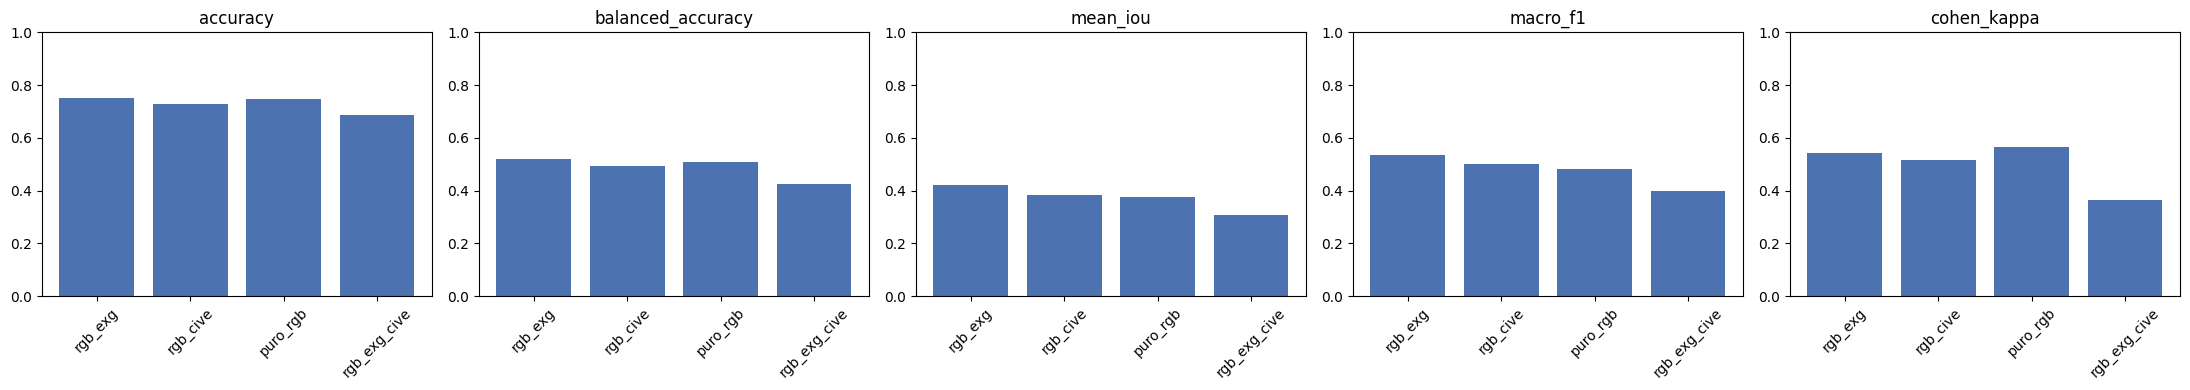

In [8]:
# Gráfico de barras comparando as métricas-chave entre as 4 configurações
metricas_para_plotar = ['accuracy', 'balanced_accuracy', 'mean_iou', 'macro_f1', 'cohen_kappa']

fig, axes = plt.subplots(1, len(metricas_para_plotar), figsize=(22, 4))
for ax, metrica in zip(axes, metricas_para_plotar):
    valores = tabela_resumo[metrica]
    ax.bar(valores.index, valores.values, color='#4C72B0')
    ax.set_title(metrica)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

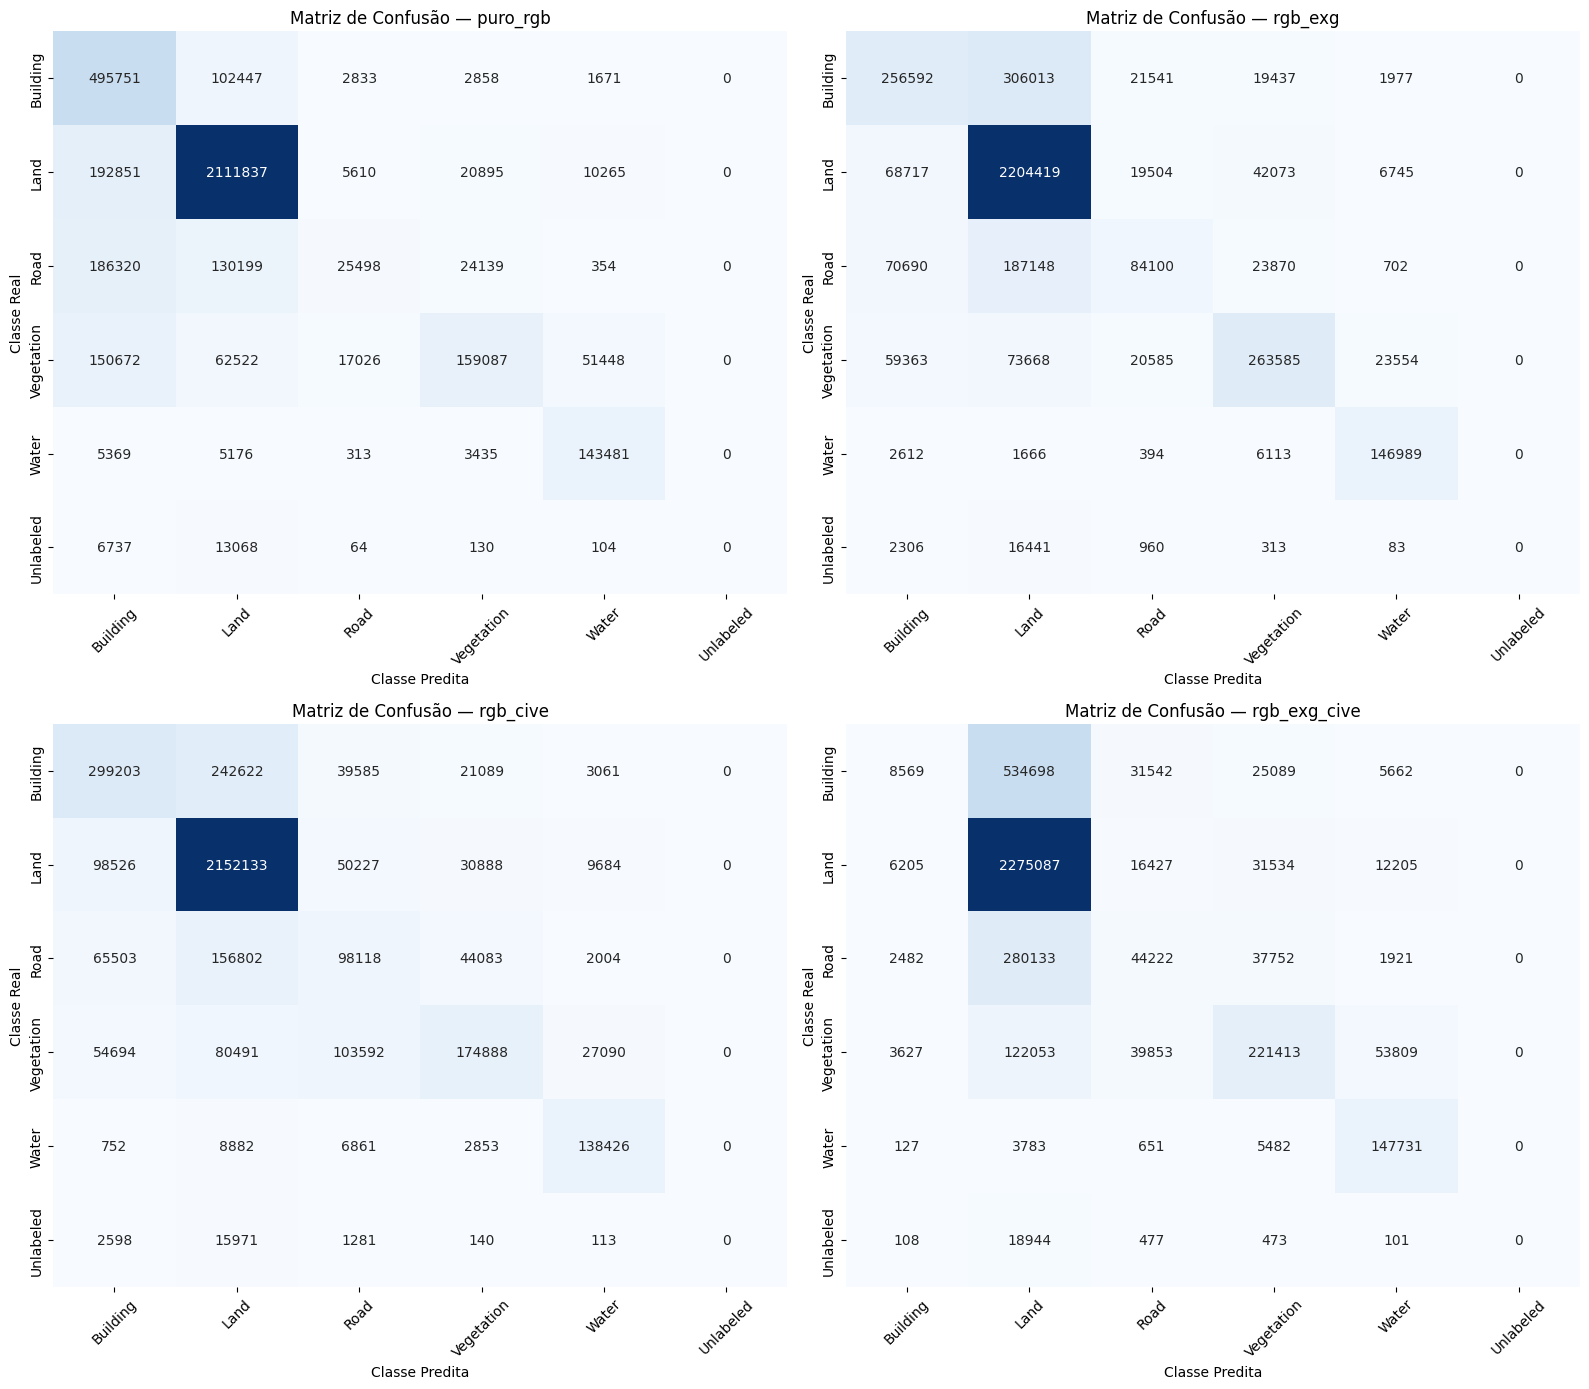

In [9]:
# Matrizes de confusão das 4 configurações, lado a lado
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
for ax, cfg in zip(axes.flat, CONFIGS):
    nome = cfg["nome"]
    plotar_matriz_confusao(resultados[nome]["cm"], class_names, titulo=f"Matriz de Confusão — {nome}", ax=ax)
plt.tight_layout()
plt.show()

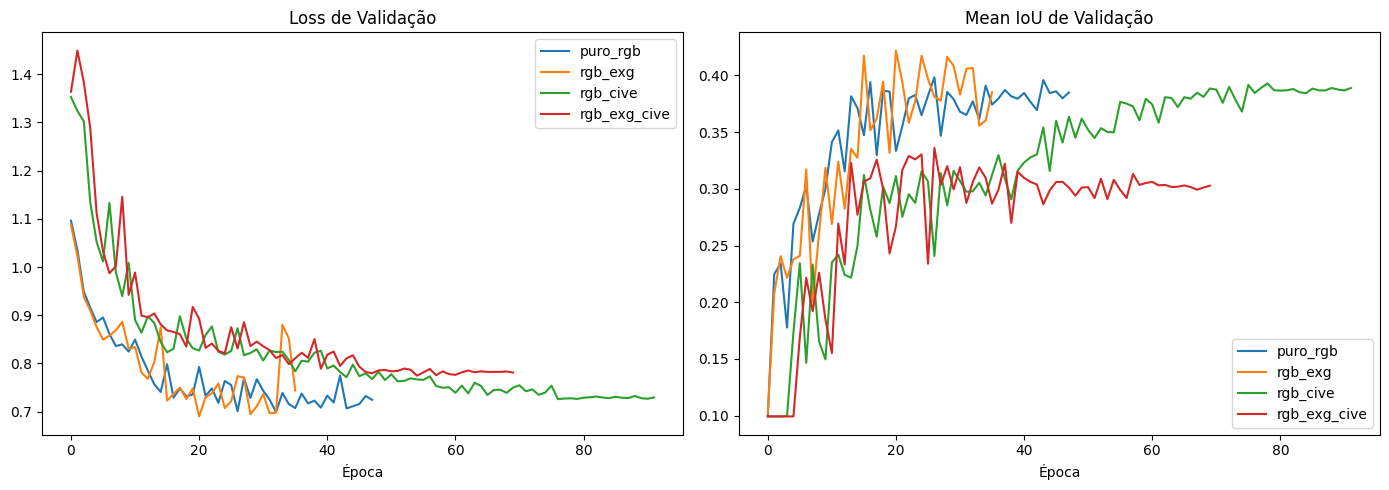

In [10]:
# Curvas de treino (loss e mean IoU de validação) sobrepostas para os 4 modelos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cfg in CONFIGS:
    nome = cfg["nome"]
    hist = resultados[nome]["history"]
    axes[0].plot(hist['val_loss'], label=nome)
    axes[1].plot(hist['val_mean_iou'], label=nome)

axes[0].set_title('Loss de Validação')
axes[0].set_xlabel('Época')
axes[0].legend()

axes[1].set_title('Mean IoU de Validação')
axes[1].set_xlabel('Época')
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
# Métricas por classe do melhor modelo (maior mean_iou), para inspecionar
# quais classes ainda concentram mais erro (ex: Building vs Road)
melhor_modelo_nome = tabela_resumo.index[0]
print(f"Melhor configuração por mean_iou: {melhor_modelo_nome}\n")
resultados[melhor_modelo_nome]["por_classe"].round(4)

Melhor configuração por mean_iou: rgb_exg



,classe,precision,recall,f1,iou
0,Building,0.5575,0.4237,0.4815,0.3171
1,Land,0.7903,0.9415,0.8593,0.7533
2,Road,0.5718,0.2295,0.3275,0.1958
3,Vegetation,0.7417,0.5980,0.6622,0.4949
4,Water,0.8164,0.9316,0.8702,0.7702
5,Unlabeled,0.0000,0.0000,0.0000,0.0000


### Predição vs. Rótulo humano (inspeção visual do melhor modelo)

A acurácia global e o mean IoU não substituem uma auditoria visual qualitativa. Abaixo, pegamos o modelo com melhor `mean_iou` e comparamos, lado a lado, a imagem RGB, a máscara real e a predição, para um lote não visto no treinamento.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 681ms/step


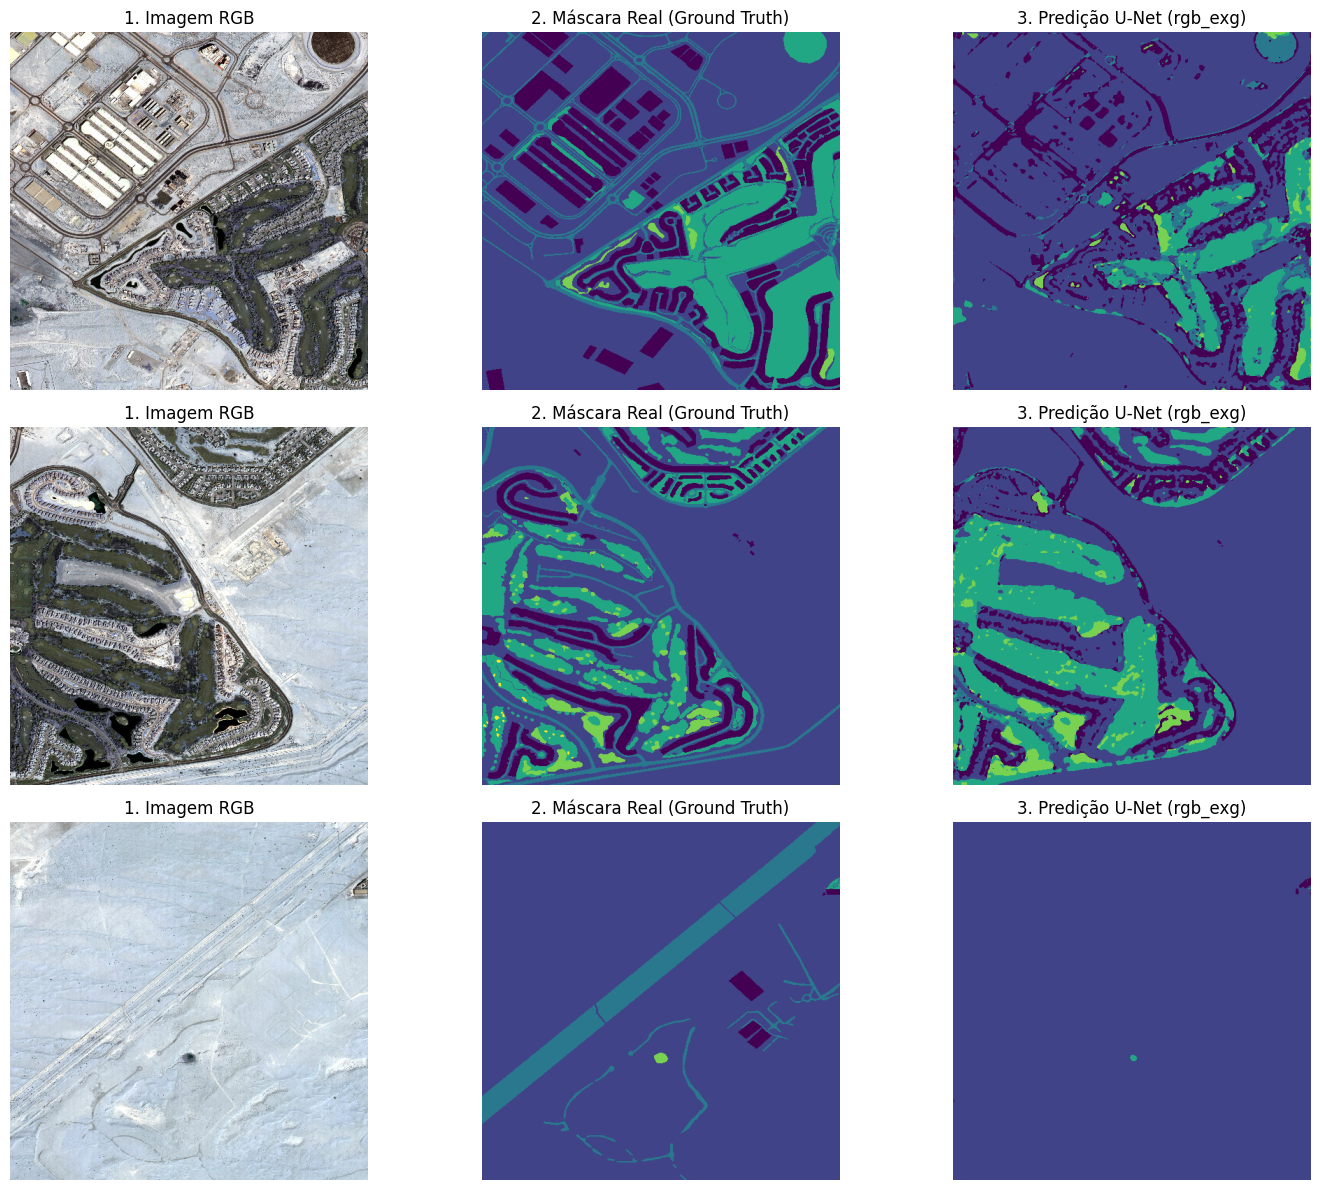

In [12]:
melhor_modelo = resultados[melhor_modelo_nome]["modelo"]
melhor_cfg = next(c for c in CONFIGS if c["nome"] == melhor_modelo_nome)
_, val_dataset_melhor = montar_pipeline(melhor_cfg["use_exg"], melhor_cfg["use_cive"])

for images, masks in val_dataset_melhor.take(1):
    preds = melhor_modelo.predict(images)
    preds_classes = np.argmax(preds, axis=-1)

    plt.figure(figsize=(15, 12))
    for i in range(3):
        plt.subplot(3, 3, i * 3 + 1)
        plt.imshow(images[i][:, :, :3])
        plt.title("1. Imagem RGB", fontsize=12)
        plt.axis('off')

        plt.subplot(3, 3, i * 3 + 2)
        plt.imshow(masks[i], cmap='viridis', vmin=0, vmax=num_classes - 1)
        plt.title("2. Máscara Real (Ground Truth)", fontsize=12)
        plt.axis('off')

        plt.subplot(3, 3, i * 3 + 3)
        plt.imshow(preds_classes[i], cmap='viridis', vmin=0, vmax=num_classes - 1)
        plt.title(f"3. Predição U-Net ({melhor_modelo_nome})", fontsize=12)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

## Conclusão e Próximos Passos

**Múltiplas Configurações de Entrada:** o experimento agora treina e compara 4 variantes de canais de entrada (RGB puro, RGB+ExG, RGB+CIVE, RGB+ExG+CIVE) sob as mesmas condições de arquitetura, callbacks e conjunto de validação, permitindo isolar o efeito real de cada índice espectral.

**Métricas além da Acurácia:** a avaliação agora inclui Mean IoU, Balanced Accuracy, Precision/Recall/F1 (globais e por classe) e Cohen's Kappa, expondo desbalanceamentos e confusões entre classes que a acurácia de pixel escondia.

**Limitações de Resolução Física:** Devido ao *downsampling* necessário para a prototipagem local (redução da imagem para 512x512 pixels), micro-estruturas urbanas (como ruas de poucos metros de largura) continuam sendo um desafio para todas as configurações.

**Próximos passos sugeridos:**
* Rodar validação cruzada (k-fold) para checar a estabilidade do ranking entre as 4 configurações.
* Testar `class_weight` ou uma *loss* ponderada (ex: Focal Loss / Dice Loss) para lidar melhor com classes raras como "Water".
* Avaliar se ganhos de ExG/CIVE se mantêm em resoluções maiores que 512x512.